In [37]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [50]:
qubit_counts = [2,3,4,5,6,7,8,10,12,14,16,18,20,22,24,26]
n_qubits = 12
n_layers = 2
n_trials = 200

In [51]:
def create_circuit(n_qubits, n_layers):

    dev = qml.device("lightning.gpu",wires = n_qubits, c_dtype=np.complex64)

    @qml.qnode(dev, diff_method="adjoint")
    def circuit(weights):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.RY(weights[layer, q],wires=q)

            for q in range(n_qubits-1):
                qml.CNOT(wires=[q,q + 1])

        return qml.expval(qml.PauliZ(0))
    return circuit

In [52]:
circuit = create_circuit(n_qubits, n_layers)

weights =  np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits))

epsilon = 1e-5

weights_plus = weights.copy()
weights_plus[0,0] += epsilon
        
cost_plus = circuit(weights_plus)
        
weights_minus = weights.copy()
weights_minus[0,0] -= epsilon
        
cost_minus = circuit(weights_minus)
        
gradient = (cost_plus - cost_minus) / (2*epsilon)

print("Weights shape:",weights.shape)
print("Cost +",cost_plus)
print("Cost -",cost_minus)
print(gradient)

Weights shape: (2, 12)
Cost + -0.2824743688106537
Cost - -0.2824583351612091
-0.8016824722290038


In [48]:
def run_single_gradient_experiment(n_qubits, n_layers, n_trials):

    circuit = create_circuit(n_qubits,n_layers)
    
    all_gradients = []

    epsilon = 1e-5
    
    for trial in range(n_trials):
        
        
        weights_plus = weights.copy()
        weights_plus[0,0] += epsilon
        
        cost_plus = circuit(weights_plus)
        
        weights_minus = weights.copy()
        weights_minus[0,0] -= epsilon
        
        cost_minus = circuit(weights_minus)
        
        gradient = (cost_plus - cost_minus) / (2*epsilon)
        
        all_gradients.append(gradient)
        
   # qml.draw_mpl(circuit,style='pennylane')(weights);
    
    return np.array(all_gradients)

In [ ]:
gradients = run_single_gradient_experiment(n_qubits=n_qubits, n_layers=n_layers,n_trials=n_trials)

In [49]:
results = []

for n_qubits in qubit_counts:

    print(f"Running {n_qubits} qubits...")

    gradients = run_single_gradient_experiment(n_qubits=n_qubits, n_layers=n_layers,n_trials=n_trials)

    mean_gradient = np.mean(gradients)
    variance = np.var(gradients)

    results.append({"Qubits": n_qubits,"Variance": variance,"Mean Gradient": mean_gradient})

    print(f"Mean = {mean_gradient:.6e}, "f"Variance = {variance}")

    results_df = pd.DataFrame(results)

    display(results_df)

Running 2 qubits...
Mean = 4.082918e-01, Variance = 0.0


,Qubits,Variance,Mean Gradient
0,2,0.0,0.4082918167114257


Running 3 qubits...
Mean = 4.172325e-01, Variance = 0.0


,Qubits,Variance,Mean Gradient
0,2,0.0,0.4082918167114257
1,3,0.0,0.4172325134277343


Running 4 qubits...
Mean = 4.172325e-01, Variance = 0.0


...

,Qubits,Variance,Mean Gradient
0,2,0.0,0.4082918167114257
1,3,0.0,0.4172325134277343
2,4,0.0,0.4172325134277343
3,5,0.0,0.4142522811889648
4,6,0.0,0.4142522811889648
5,7,0.0,0.4172325134277343
6,8,0.0,0.4172325134277343


Running 10 qubits...
Mean = 4.172325e-01, Variance = 0.0


,Qubits,Variance,Mean Gradient
0,2,0.0,0.4082918167114257
1,3,0.0,0.4172325134277343
2,4,0.0,0.4172325134277343
3,5,0.0,0.4142522811889648
4,6,0.0,0.4142522811889648
5,7,0.0,0.4172325134277343
6,8,0.0,0.4172325134277343
7,10,0.0,0.4172325134277343


Running 12 qubits...


IndexError: index 10 is out of bounds for axis 1 with size 10

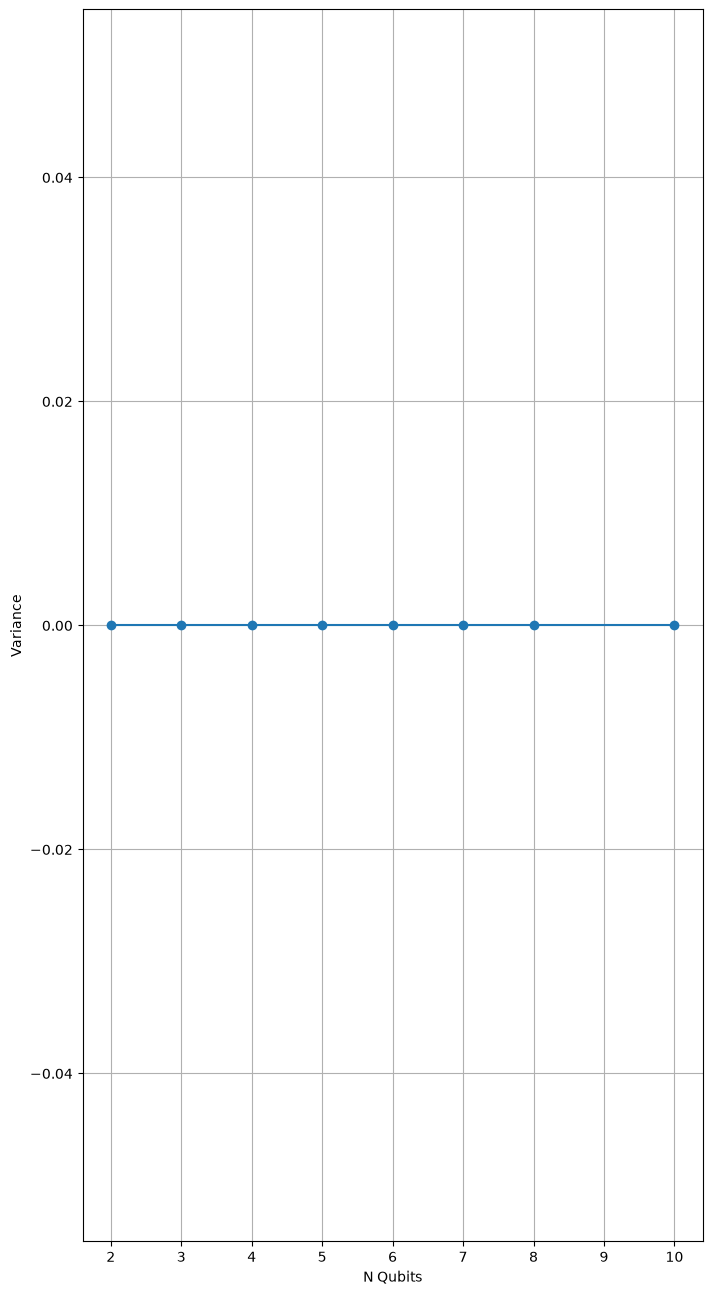

In [54]:
qubits = np.array([r["Qubits"] for r in results])
variances = np.array([r["Variance"] for r in results])

plt.figure(figsize=(8,len(qubit_counts)))

plt.plot(qubits,variances,marker="o")
#plt.yscale("log")

plt.xlabel("N Qubits")
plt.ylabel("Variance")

plt.grid(True)
plt.show()